<a href="https://colab.research.google.com/github/fariya09ahmed-commits/Fariya-Ahmed/blob/main/paper1_dengue_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
df = pd.read_csv('/content/drive/MyDrive/paper1 data dengue detenction hematological data set.csv')

## understand the data

In [24]:
df.shape
df.columns


Index(['Gender', 'Age', 'Hemoglobin(g/dl)', 'Neutrophils(%)', 'Lymphocytes(%)',
       'Monocytes(%)', 'Eosinophils(%)', 'RBC', 'HCT(%)', 'MCV(fl)', 'MCH(pg)',
       'MCHC(g/dl)', 'RDW-CV(%)', 'Total Platelet Count(/cumm)', 'MPV(fl)',
       'PDW(%)', 'PCT(%)', 'Total WBC count(/cumm)', 'Result'],
      dtype='object')

In [25]:
df.describe()

,Age,Hemoglobin(g/dl),Neutrophils(%),Lymphocytes(%),Monocytes(%),Eosinophils(%),RBC,HCT(%),MCV(fl),MCH(pg),MCHC(g/dl),RDW-CV(%),Total Platelet Count(/cumm),MPV(fl),PDW(%),PCT(%),Total WBC count(/cumm)
count,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000
mean,40.310571,14.513451,44.484570,43.559422,3.270519,3.083388,4.765594,45.189280,89.815561,29.897225,32.050271,13.635792,173127.170716,9.588806,15.312966,0.289080,5483.024951
std,15.286190,1.627142,4.344736,4.972815,1.209507,1.000791,0.722874,3.566435,5.515619,2.026022,1.551697,1.430746,64832.681751,0.848706,1.405457,5.992864,1137.344040
min,5.000000,10.400000,29.000000,29.000000,2.000000,1.000000,4.000000,36.300000,80.000000,22.900000,27.080000,11.000000,56000.000000,7.500000,8.400000,0.000020,3500.000000
25%,28.000000,13.200000,42.000000,41.000000,2.000000,2.000000,4.000000,42.595000,85.100000,28.400000,30.900000,12.400000,114907.000000,8.900000,14.230000,0.106000,4626.000000
50%,39.000000,14.600000,45.000000,44.000000,3.000000,3.000000,5.000000,45.550000,89.700000,30.000000,32.000000,13.800000,167385.000000,9.660000,15.260000,0.141000,5397.000000
75%,53.000000,15.800000,48.000000,47.000000,4.000000,4.000000,5.000000,47.840000,94.200000,31.400000,33.200000,14.700000,228649.500000,10.283000,16.400000,0.173000,6131.500000
max,78.000000,17.500000,60.000000,56.000000,9.000000,9.000000,7.000000,51.980000,100.000000,34.000000,35.000000,21.330000,299803.000000,11.235000,17.990000,234.000000,14900.000000


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1523 entries, 0 to 1522
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       1523 non-null   object 
 1   Age                          1523 non-null   int64  
 2   Hemoglobin(g/dl)             1523 non-null   float64
 3   Neutrophils(%)               1523 non-null   int64  
 4   Lymphocytes(%)               1523 non-null   int64  
 5   Monocytes(%)                 1523 non-null   int64  
 6   Eosinophils(%)               1523 non-null   int64  
 7   RBC                          1523 non-null   int64  
 8   HCT(%)                       1523 non-null   float64
 9   MCV(fl)                      1523 non-null   float64
 10  MCH(pg)                      1523 non-null   float64
 11  MCHC(g/dl)                   1523 non-null   float64
 12  RDW-CV(%)                    1523 non-null   float64
 13  Total Platelet Cou

In [27]:
df.dtypes

,0
Gender,object
Age,int64
Hemoglobin(g/dl),float64
Neutrophils(%),int64
Lymphocytes(%),int64
Monocytes(%),int64
Eosinophils(%),int64
RBC,int64
HCT(%),float64
MCV(fl),float64


## Label Encoding

In [40]:

from sklearn.preprocessing import LabelEncoder

# For yes/no or male/female (2 categories only)
label_encoder = LabelEncoder()

In [50]:
# Convert 'smoker' column
df['Result_encoded'] = label_encoder.fit_transform(df['Result'])
print("\nAfter Label Encoding 'Result':")
print(df[['Result', 'Result_encoded']])
# no = 0, yes = 1

# Convert 'gender' column
df['Gender_encoded'] = label_encoder.fit_transform(df['Gender'])
print("\nAfter Label Encoding 'Gender':")
print(df[['Gender', 'Gender_encoded']])
# female = 0, male = 1


After Label Encoding 'Result':
        Result  Result_encoded
0     positive               1
1     positive               1
2     negative               0
3     negative               0
4     negative               0
...        ...             ...
1518  positive               1
1519  positive               1
1520  positive               1
1521  positive               1
1522  positive               1

[1523 rows x 2 columns]

After Label Encoding 'Gender':
      Gender  Gender_encoded
0          1               1
1          1               1
2          1               1
3          0               0
4          1               1
...      ...             ...
1518       0               0
1519       1               1
1520       1               1
1521       1               1
1522       1               1

[1523 rows x 2 columns]


In [61]:
# 2. LabelEncoder initialize kora
le = LabelEncoder()

# 3. Gender Encoding
# Ekhane 'Male'/'Female' ke 0 ebong 1 e convert kora hobe
df['Gender'] = le.fit_transform(df['Gender'])
print("Gender Encoding Classes:", le.classes_) # Dekhbe 'Female' = 0, 'Male' = 1 (Alphabetical order)

# 4. Result Encoding
# Ekhane 'Positive'/'Negative' ke 0 ebong 1 e convert kora hobe
df['Result'] = le.fit_transform(df['Result'])
print("Result Encoding Classes:", le.classes_)

# 5. Check kora (Prothom 5ti row)
print("\nEncoded Data:")
print(df[['Gender', 'Result']].head())

Gender Encoding Classes: [0 1]
Result Encoding Classes: [0 1]

Encoded Data:
   Gender  Result
0       1       1
1       1       1
2       1       0
3       0       0
4       1       0


## Train and Test split

In [53]:
# Separate input (X) and output (y)
X = df.drop(['Gender','Result','Result_encoded','Lymphocytes(%)','RDW-CV(%)','MCHC(g/dl)','PDW(%)','Total WBC count(/cumm)'], axis=1)  # Everything except Outcome
y = df['Result_encoded']                # Only Outcome

print("X has all patient information (18 columns)")
print("y has dengue yes/no (1 column)")

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for test
    random_state=20   # Same result every time
)

print(f"\nWe will train with: {len(X_train)} patients")
print(f"We will test with: {len(X_test)} patients")

X has all patient information (18 columns)
y has dengue yes/no (1 column)

We will train with: 1218 patients
We will test with: 305 patients


## Standard Scaler

In [87]:
# Create scaler
scaler = StandardScaler()

# Learn from training data and scale it
X_train_scaled = scaler.fit_transform(X_train)

# Scale test data (just transform, don't fit)
X_test_scaled = scaler.transform(X_test)

print("\nAfter scaling:")
print("All features now have similar range!")
print(f"Example - First patient's Age before scaling: {X_train.values[0][7]}")
print(f"Example - First patient's Age after scaling: {X_train_scaled[0][7]:.2f}")


After scaling:
All features now have similar range!
Example - First patient's Age before scaling: 85.4
Example - First patient's Age after scaling: -0.79


## Outlier

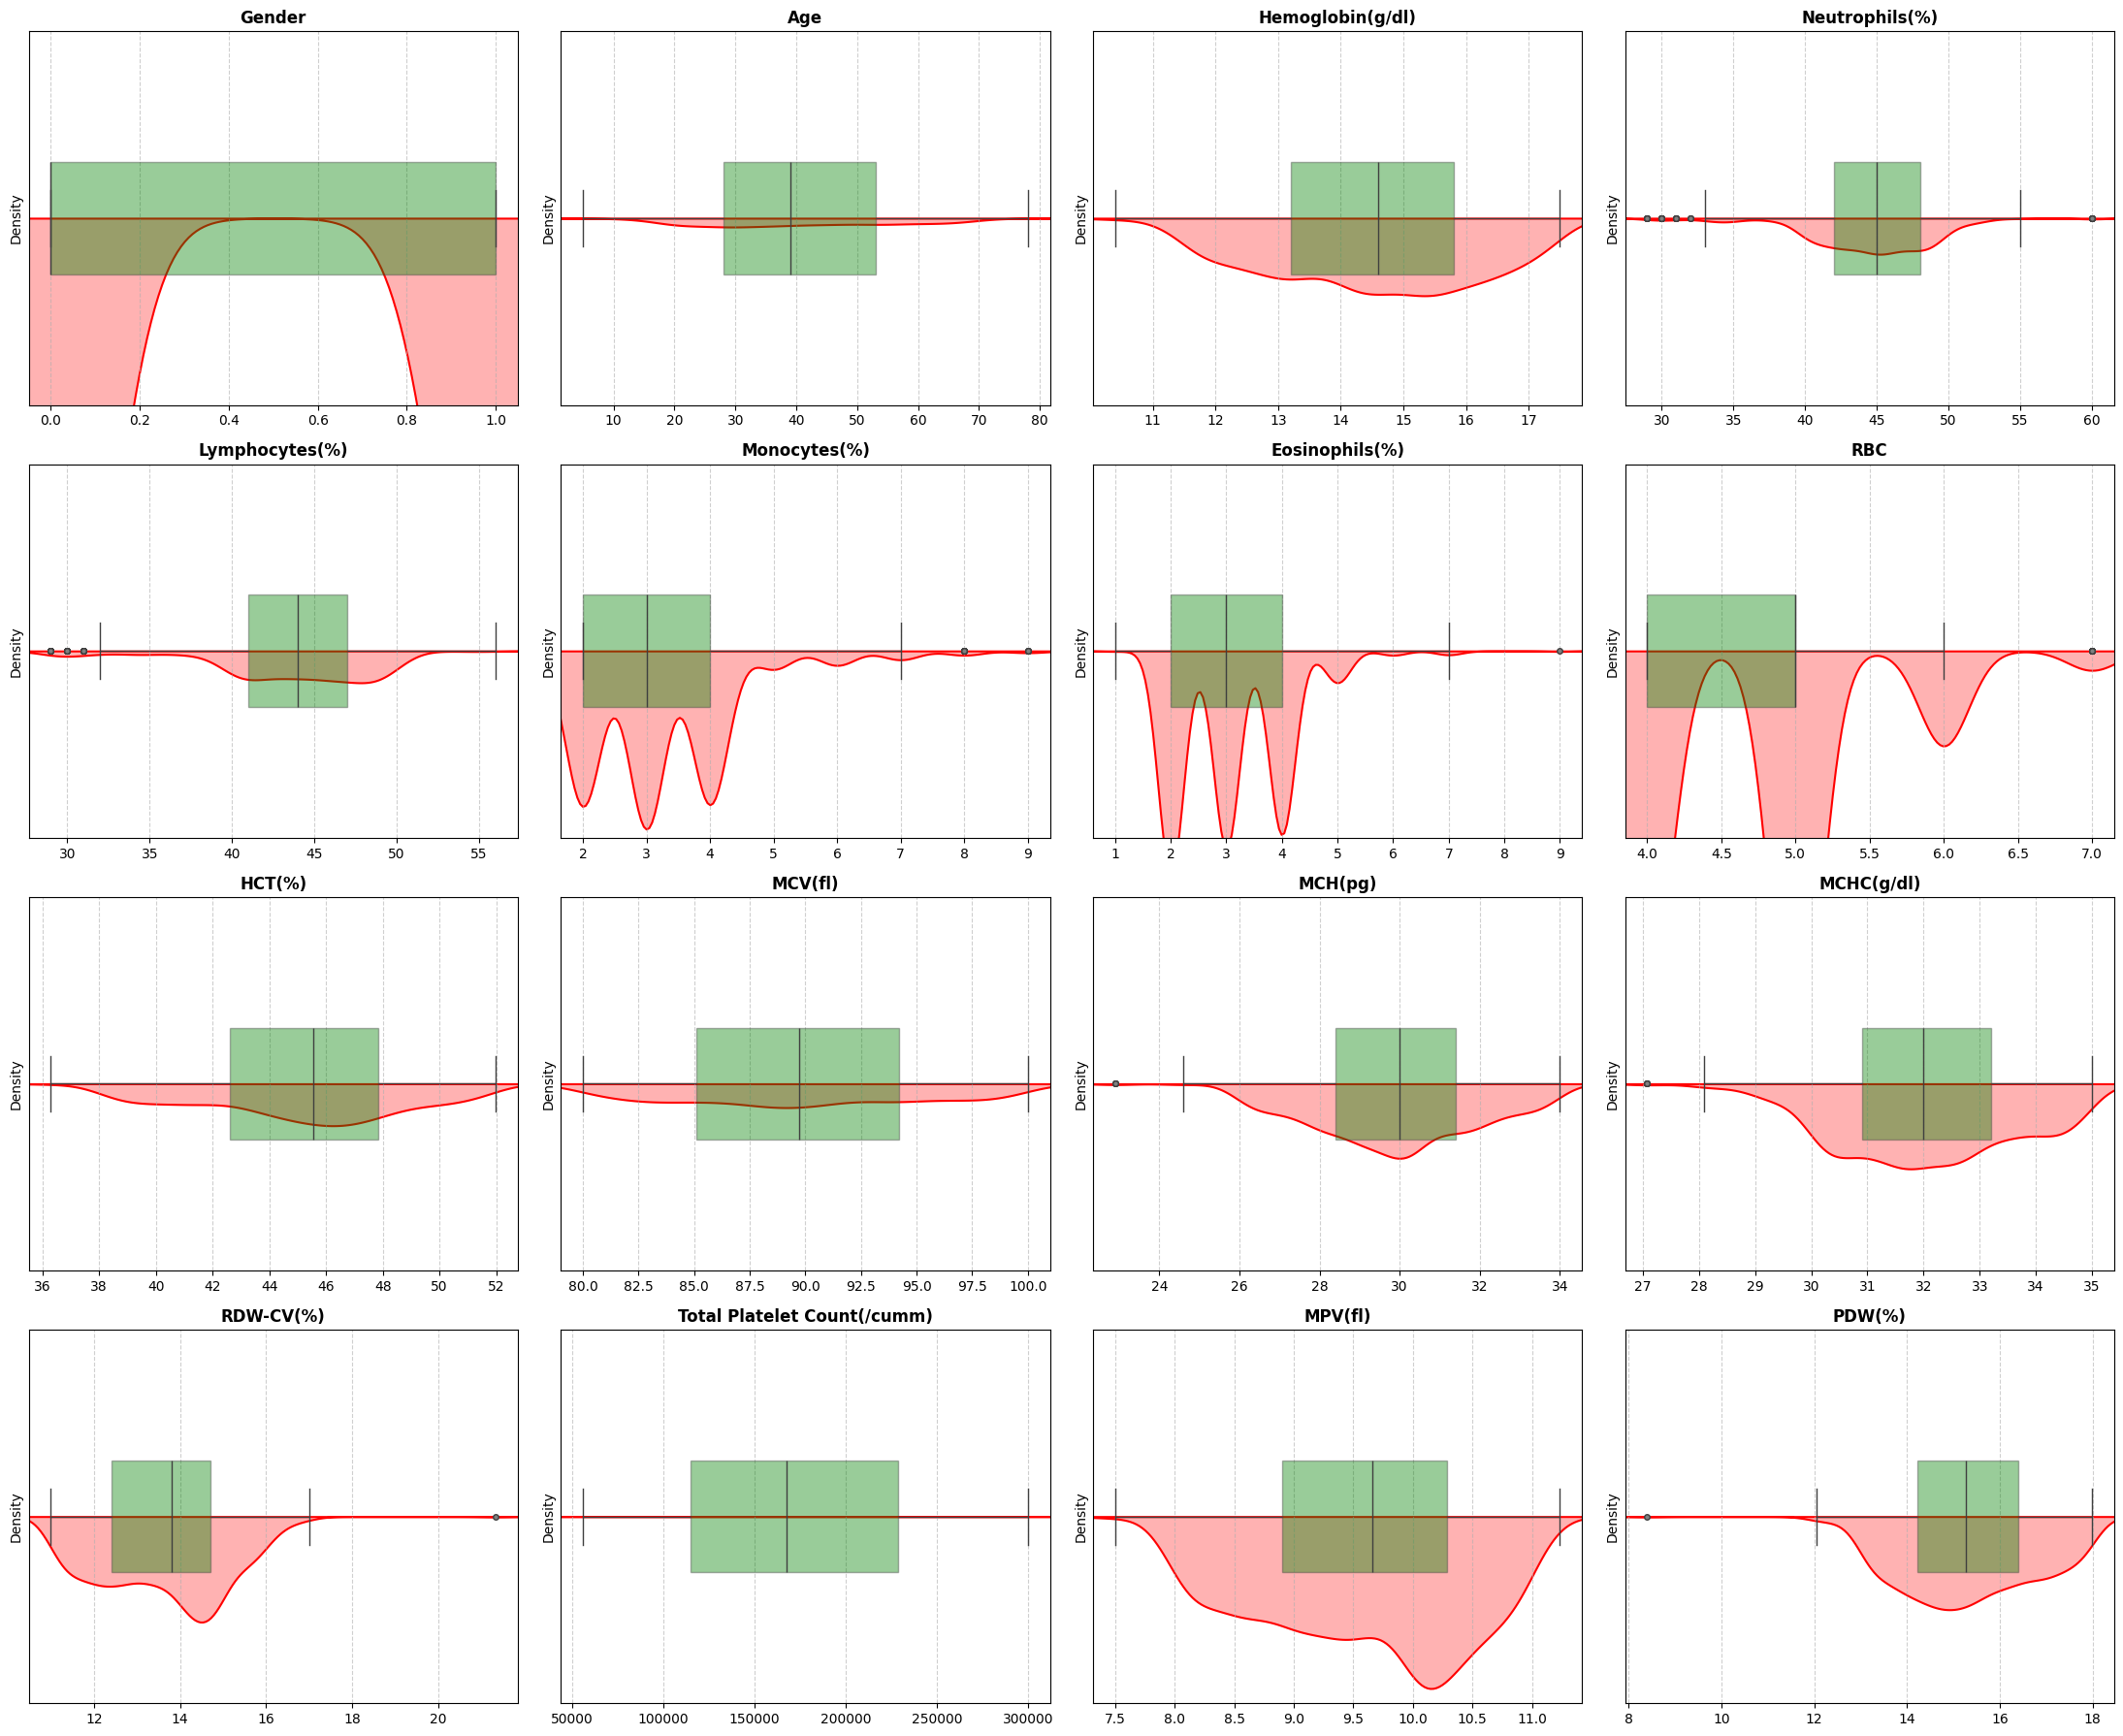

In [60]:
# 2. Gender Encoding (Male = 0, Female = 1 or vice-versa)
# Dataset-e jodi 'Male'/'Female' thake tobe eta numerical hoye jabe
if df['Gender'].dtype == 'object':
    df['Gender'] = df['Gender'].astype('category').cat.codes
    print("Gender column encoded to numerical values.")

# 3. Column list update (Age theke PDW porjonto)
cols_to_plot = [
    'Gender', 'Age', 'Hemoglobin(g/dl)', 'Neutrophils(%)',
    'Lymphocytes(%)', 'Monocytes(%)', 'Eosinophils(%)', 'RBC',
    'HCT(%)', 'MCV(fl)', 'MCH(pg)', 'MCHC(g/dl)',
    'RDW-CV(%)', 'Total Platelet Count(/cumm)', 'MPV(fl)', 'PDW(%)'
]

# 4. Grid Setup (4x4)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(22, 18))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    if col in df.columns:
        ax = axes[i]
        # Null values handle kora
        data = pd.to_numeric(df[col], errors='coerce').dropna()

        if not data.empty:
            # Layer 1: Red Density
            sns.kdeplot(data, ax=ax, fill=True, color="red", alpha=0.3, linewidth=1.5)

            # Layer 2: Green Boxplot
            sns.boxplot(x=data, ax=ax, width=0.3,
                        boxprops={'facecolor':'green', 'alpha':0.4},
                        showfliers=True,
                        flierprops={'marker':'o', 'markerfacecolor':'gray', 'markersize':4})

            ax.set_title(col, fontsize=12, fontweight='bold')
            ax.set_ylabel('Density')
            ax.set_xlabel('')
            ax.set_yticks([])
            ax.grid(axis='x', linestyle='--', alpha=0.6)

# Empty plots remove kora
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## outlier removal

In [77]:
cols = ['Neutrophils(%)','Lymphocytes(%)','Monocytes(%)','Eosinophils(%)','RBC','MCH(pg)','MCHC(g/dl)', 'RDW-CV(%)', 'RDW-CV(%)','PDW(%)',]

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[cols] < (Q1 - 1.5 * IQR)) |
                (df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [78]:
print("Before:", df.shape[0])
print("After:", df_clean.shape[0])
print("Removed:", df.shape[0] - df_clean.shape[0])

Before: 1523
After: 1372
Removed: 151


Original data size: 1523
Cleaned data size: 1372


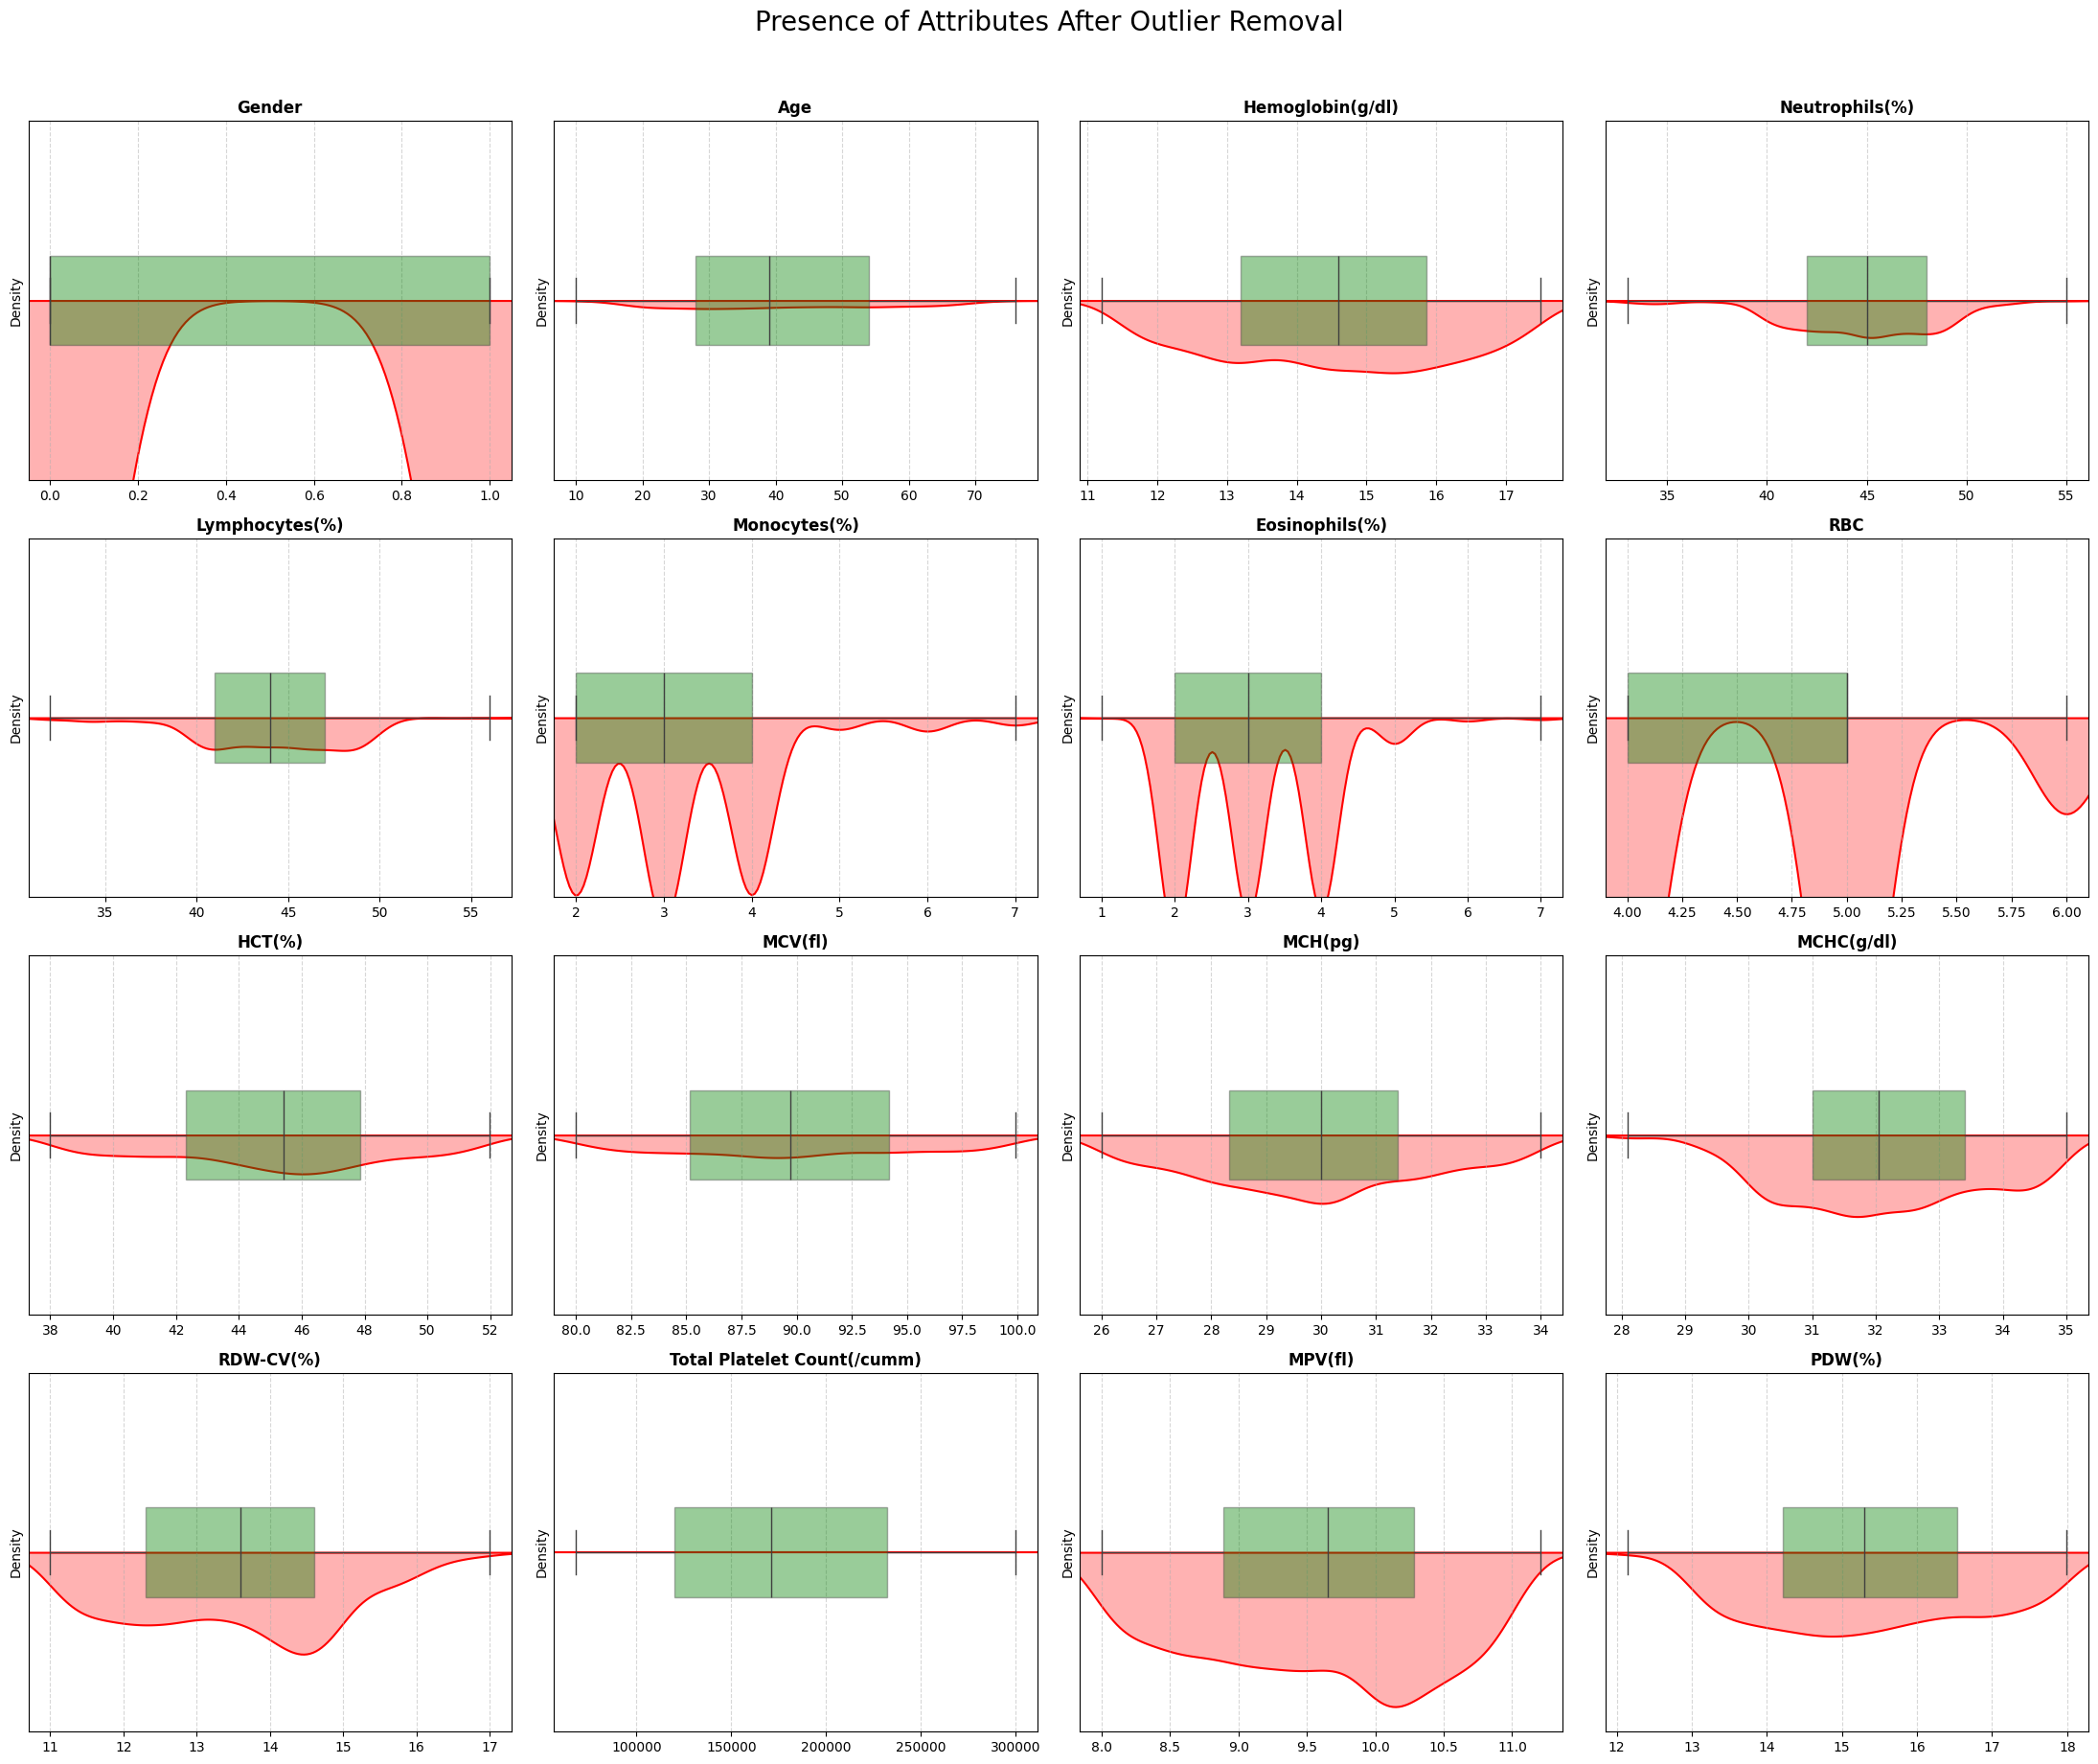

In [86]:
# 3. Outlier Removal using IQR
cols_to_check = [
    'Gender','Age', 'Hemoglobin(g/dl)', 'Neutrophils(%)', 'Lymphocytes(%)',
    'Monocytes(%)', 'Eosinophils(%)', 'RBC', 'HCT(%)', 'MCV(fl)',
    'MCH(pg)', 'MCHC(g/dl)', 'RDW-CV(%)', 'Total Platelet Count(/cumm)',
    'MPV(fl)', 'PDW(%)'
]

Q1 = df[cols_to_check].quantile(0.25)
Q3 = df[cols_to_check].quantile(0.75)
IQR = Q3 - Q1

# Filter out outliers
df_cleaned = df[~((df[cols_to_check] < (Q1 - 1.5 * IQR)) | (df[cols_to_check] > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"Original data size: {len(df)}")
print(f"Cleaned data size: {len(df_cleaned)}")

# 4. Plotting the Cleaned Data (Thik ager style-e)
# Fix: cols_to_check already contains 'Gender', so directly assign it to cols_to_plot
cols_to_plot = cols_to_check

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(22, 18))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    if col in df_cleaned.columns:
        ax = axes[i]
        data = df_cleaned[col].dropna()

        # Layer 1: Red Density
        sns.kdeplot(data, ax=ax, fill=True, color="red", alpha=0.3, linewidth=1.5)

        # Layer 2: Green Boxplot
        sns.boxplot(x=data, ax=ax, width=0.25,
                    boxprops={'facecolor':'green', 'alpha':0.4},
                    showfliers=True) # Ekhon fliers/dots thakar kotha na

        ax.set_title(col, fontsize=12, fontweight='bold')
        ax.set_ylabel('Density')
        ax.set_xlabel('')
        ax.set_yticks([])
        ax.grid(axis='x', linestyle='--', alpha=0.5)

# Khali plots remove kora
# This loop will now correctly iterate for any remaining empty subplots if num_cols < nrows*ncols
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Presence of Attributes After Outlier Removal", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

Result
1    1042
0     481
Name: count, dtype: int64


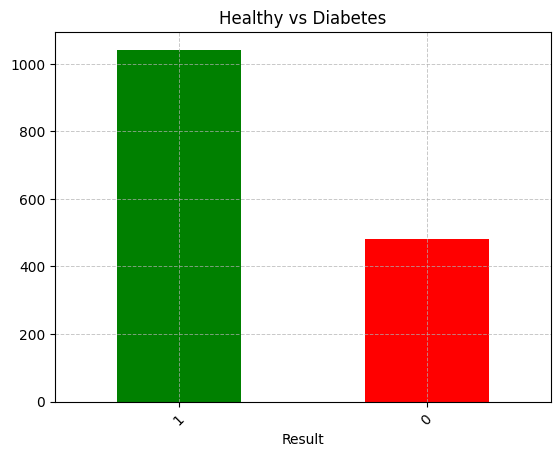

In [91]:
# Show distribution
print(df['Result'].value_counts())

# Plot
df['Result'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Healthy vs Diabetes')
plt.xticks([0, 1], rotation=45)
plt.grid(True,which="both", linestyle="--",linewidth=0.7, alpha=0.7)
plt.show()

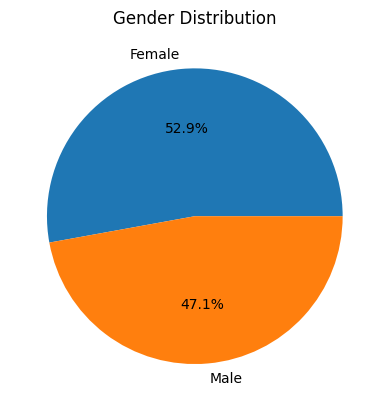

In [93]:
# With percentages
plt.pie(df['Gender'].value_counts().values, labels=['Female', 'Male'], autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.savefig('Gender Distribution.png', dpi=300, bbox_inches='tight')
plt.show()